# GOES-R ABI — catalog explorer (no network)

The [`earthlens.goes`](../../reference/goes/introduction.md) backend fetches raw
**NOAA GOES-R ABI** NetCDF granules from the anonymous `noaa-goes*` AWS buckets.
Before downloading anything, it helps to understand the three axes of a GOES
request — **satellite**, **product**, and **domain** — and the spectral bands
the imager carries.

This notebook is **fully offline**: it only reads the bundled catalog
(`earthlens.goes.Catalog`). By the end you will know which products, domains,
satellites, and ABI channels are available, and how they map to an S3 key.

## Setup

Load the catalog and pandas for tidy tables.

In [1]:
import pandas as pd

from earthlens.goes import Catalog

cat = Catalog()
cat  # a compact repr: how many products / available datasets

Catalog(datasets=17, available_datasets=17)

## Products

A GOES request names a **product family** with `dataset=`. Each row maps a
friendly key to its ABI `product_group` (the S3 prefix stem), the processing
level, and the domains it publishes. `band_split` marks the products that store
**one file per ABI channel** (so `variables=` selects which channels to fetch).

In [2]:
products = pd.DataFrame(
    [
        {
            "dataset": key,
            "product_group": p.product_group,
            "level": p.level,
            "domains": ", ".join(p.domains),
            "band_split": p.band_split,
            "description": p.description.split(" - ")[0],
        }
        for key, p in sorted(cat.datasets.items())
    ]
)
products

,dataset,product_group,level,domains,band_split,description
0,abi-l1b-rad,ABI-L1b-Rad,L1b,"C, F, M1, M2",True,ABI radiances (Level-1b)
1,abi-l2-acha,ABI-L2-ACHA,L2,"C, F, M1, M2",False,Cloud Top Height.
2,abi-l2-acm,ABI-L2-ACM,L2,"C, F, M1, M2",False,Clear Sky Mask.
3,abi-l2-actp,ABI-L2-ACTP,L2,"C, F, M1, M2",False,Cloud Top Phase.
4,abi-l2-adp,ABI-L2-ADP,L2,"C, F, M1, M2",False,Aerosol Detection (smoke / dust) product.
5,abi-l2-aod,ABI-L2-AOD,L2,"C, F",False,Aerosol Optical Depth at 550 nm.
6,abi-l2-cmip,ABI-L2-CMIP,L2,"C, F, M1, M2",True,Cloud & Moisture Imagery (single-band)
7,abi-l2-cod,ABI-L2-COD,L2,"C, F",False,Cloud Optical Depth.
8,abi-l2-cps,ABI-L2-CPS,L2,"C, F, M1, M2",False,Cloud Particle Size distribution.
9,abi-l2-dmw,ABI-L2-DMW,L2,"C, F, M1, M2",False,Derived Motion Winds.


## Domains

ABI scans four **domains**. CONUS (`C`) and Full Disk (`F`) each have their own
S3 prefix suffix; the two Mesoscale sub-sectors (`M1`, `M2`) **share** one `…M`
prefix and are told apart by a filename token. Cadence is informational — the
backend lists the actual hour prefix rather than computing an expected count.

In [3]:
domains = pd.DataFrame(
    [
        {
            "domain": key,
            "name": d.name,
            "cadence_minutes": d.cadence_minutes,
            "prefix_suffix": d.prefix_suffix,
            "subsector": d.subsector or "-",
        }
        for key, d in cat.domains.items()
    ]
)
domains

,domain,name,cadence_minutes,prefix_suffix,subsector
0,C,CONUS,5.0,C,-
1,F,Full Disk,10.0,F,-
2,M1,Mesoscale 1,1.0,M,M1
3,M2,Mesoscale 2,1.0,M,M2


## Satellites → buckets

`satellite=` accepts an operational **role** (`east` / `west`) or an explicit
satellite **number** (`16` / `18` / `19`). The role→bucket map lives in the
catalog because East/West rotate as new GOES satellites commission.

In [4]:
pd.DataFrame(sorted(cat.satellites.items()), columns=["satellite", "bucket"])

,satellite,bucket
0,16,noaa-goes16
1,18,noaa-goes18
2,19,noaa-goes19
3,east,noaa-goes19
4,west,noaa-goes18


## ABI spectral channels

The imager carries **16 spectral bands**. For the band-split products
(`abi-l1b-rad`, `abi-l2-cmip`) you pick channels with
`variables=["C02", "C13", ...]`. The visible / near-IR bands sit at short
wavelengths; the water-vapour and window bands are thermal-infrared.

In [5]:
channels = pd.DataFrame(
    [
        {"channel": k, "wavelength_um": c.wavelength_um, "name": c.name}
        for k, c in cat.channels.items()
    ]
)
channels

,channel,wavelength_um,name
0,C01,0.47,Blue (visible)
1,C02,0.64,Red (visible)
2,C03,0.86,Veggie (near-IR)
3,C04,1.37,Cirrus (near-IR)
4,C05,1.60,Snow/Ice (near-IR)
5,C06,2.20,Cloud particle size (near-IR)
6,C07,3.90,Shortwave window (IR)
7,C08,6.20,Upper-level water vapour (IR)
8,C09,6.90,Mid-level water vapour (IR)
9,C10,7.30,Lower-level water vapour (IR)


A quick look at where each band sits on the spectrum:

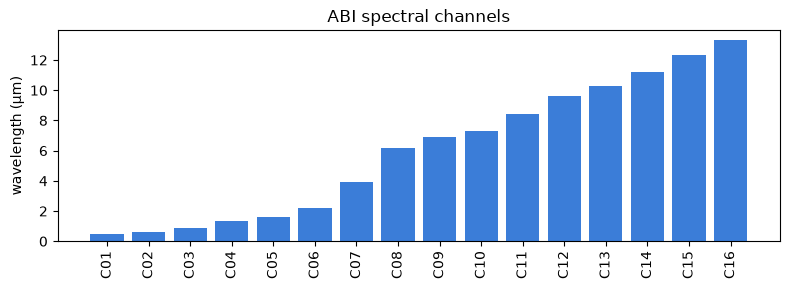

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(channels["channel"], channels["wavelength_um"], color="#3b7dd8")
ax.set_ylabel("wavelength (µm)")
ax.set_title("ABI spectral channels")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

## From a request to an S3 key (still no network)

Constructing the backend resolves the satellite to a bucket and the
product + domain to an S3 prefix — **without touching the network**. This is the
prefix the backend will list per hour of the requested window.

In [7]:
from earthlens.goes import GOES

goes = GOES(
    start="2026-07-03 12:00",
    end="2026-07-03 12:10",
    lat_lim=[20, 50],
    lon_lim=[-130, -60],
    dataset="abi-l2-mcmip",
    satellite="east",
    domain="C",
    fmt="%Y-%m-%d %H:%M",
)
print("bucket:", goes._bucket)
print("prefix:", goes._prefix())
print("hours :", [str(h) for h in goes.time.dates])

bucket: noaa-goes19
prefix: ABI-L2-MCMIPC
hours : ['2026-07-03 12:00:00']


## Takeaway

* A GOES request is **satellite × product × domain × time window**.
* `dataset=` picks the product family; `variables=` picks ABI channels for the
  band-split products; `satellite=` and `domain=` resolve to a bucket + S3
  prefix, all from the catalog.
* Next: the [CONUS granule download](conus_granule_download.ipynb) notebook
  fetches a real granule and decodes a band with pyramids.